# Разведочный анализ данных (EDA) датасета Bank Marketing

**Цель:** Изучить исходный набор данных до применения математических преобразований, рассчитать базовые статистические характеристики, оценить баланс целевой переменной и выявить визуальные зависимости между наиболее важными признаками и фактом открытия банковского вклада.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('data/bank/bank.csv', sep=';')

df.head(3)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no


## 1. Статистические характеристики набора данных
Перед построением графиков рассчитаем базовые метрики: среднее значение, стандартное отклонение, медиану, а также минимум и максимум для числовых переменных. Для категориальных переменных выведем количество уникальных значений и самую частую категорию (моду).

In [9]:
print("--- Статистика числовых признаков ---")
display(df.describe().round(2))

print("\n--- Статистика категориальных признаков ---")
display(df.describe(include=['object']))

--- Статистика числовых признаков ---


,age,balance,day,duration,campaign,pdays,previous
count,4521.00,4521.00,4521.00,4521.00,4521.00,4521.00,4521.00
mean,41.17,1422.66,15.92,263.96,2.79,39.77,0.54
std,10.58,3009.64,8.25,259.86,3.11,100.12,1.69
min,19.00,-3313.00,1.00,4.00,1.00,-1.00,0.00
25%,33.00,69.00,9.00,104.00,1.00,-1.00,0.00
50%,39.00,444.00,16.00,185.00,2.00,-1.00,0.00
75%,49.00,1480.00,21.00,329.00,3.00,-1.00,0.00
max,87.00,71188.00,31.00,3025.00,50.00,871.00,25.00



--- Статистика категориальных признаков ---


,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,4521,4521,4521,4521,4521,4521,4521,4521,4521,4521
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,yes,no,cellular,may,unknown,no
freq,969,2797,2306,4445,2559,3830,2896,1398,3705,4000


## 2. Анализ целевой переменной
Целевой переменной в данной задаче выступает признак **y** (факт открытия срочного вклада). Оценим распределение классов, чтобы выявить наличие или отсутствие дисбаланса.

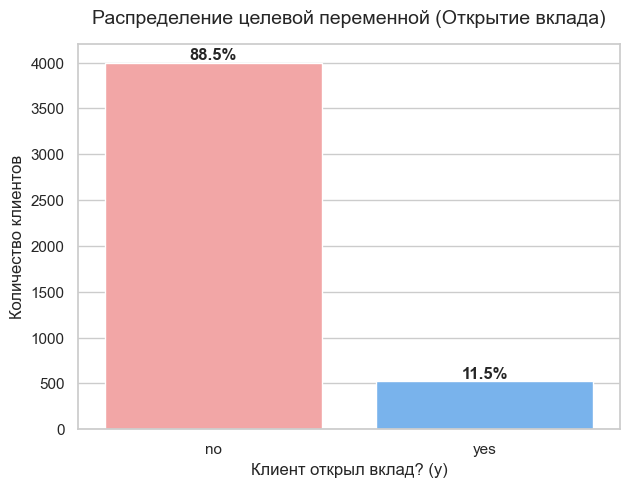

In [10]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(data=df, x='y', palette=['#ff9999', '#66b3ff'])
plt.title('Распределение целевой переменной (Открытие вклада)', fontsize=14, pad=15)
plt.xlabel('Клиент открыл вклад? (y)', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)

total_clients = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total_clients:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y_pos = p.get_height()
    ax.annotate(percentage, (x, y_pos), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

## 3. Анализ наиболее важных признаков и их связи с целевой переменной
Для детального визуального анализа выбраны 5 наиболее значимых признаков (3 числовых и 2 категориальных):
1. **duration** (длительность текущего звонка)
2. **age** (возраст клиента)
3. **balance** (баланс счета)
4. **job** (профессия)
5. **poutcome** (результат предыдущей маркетинговой кампании)

Для каждого признака построена пара графиков: слева — общее распределение признака в базе, справа — зависимость целевой переменной от этого признака.

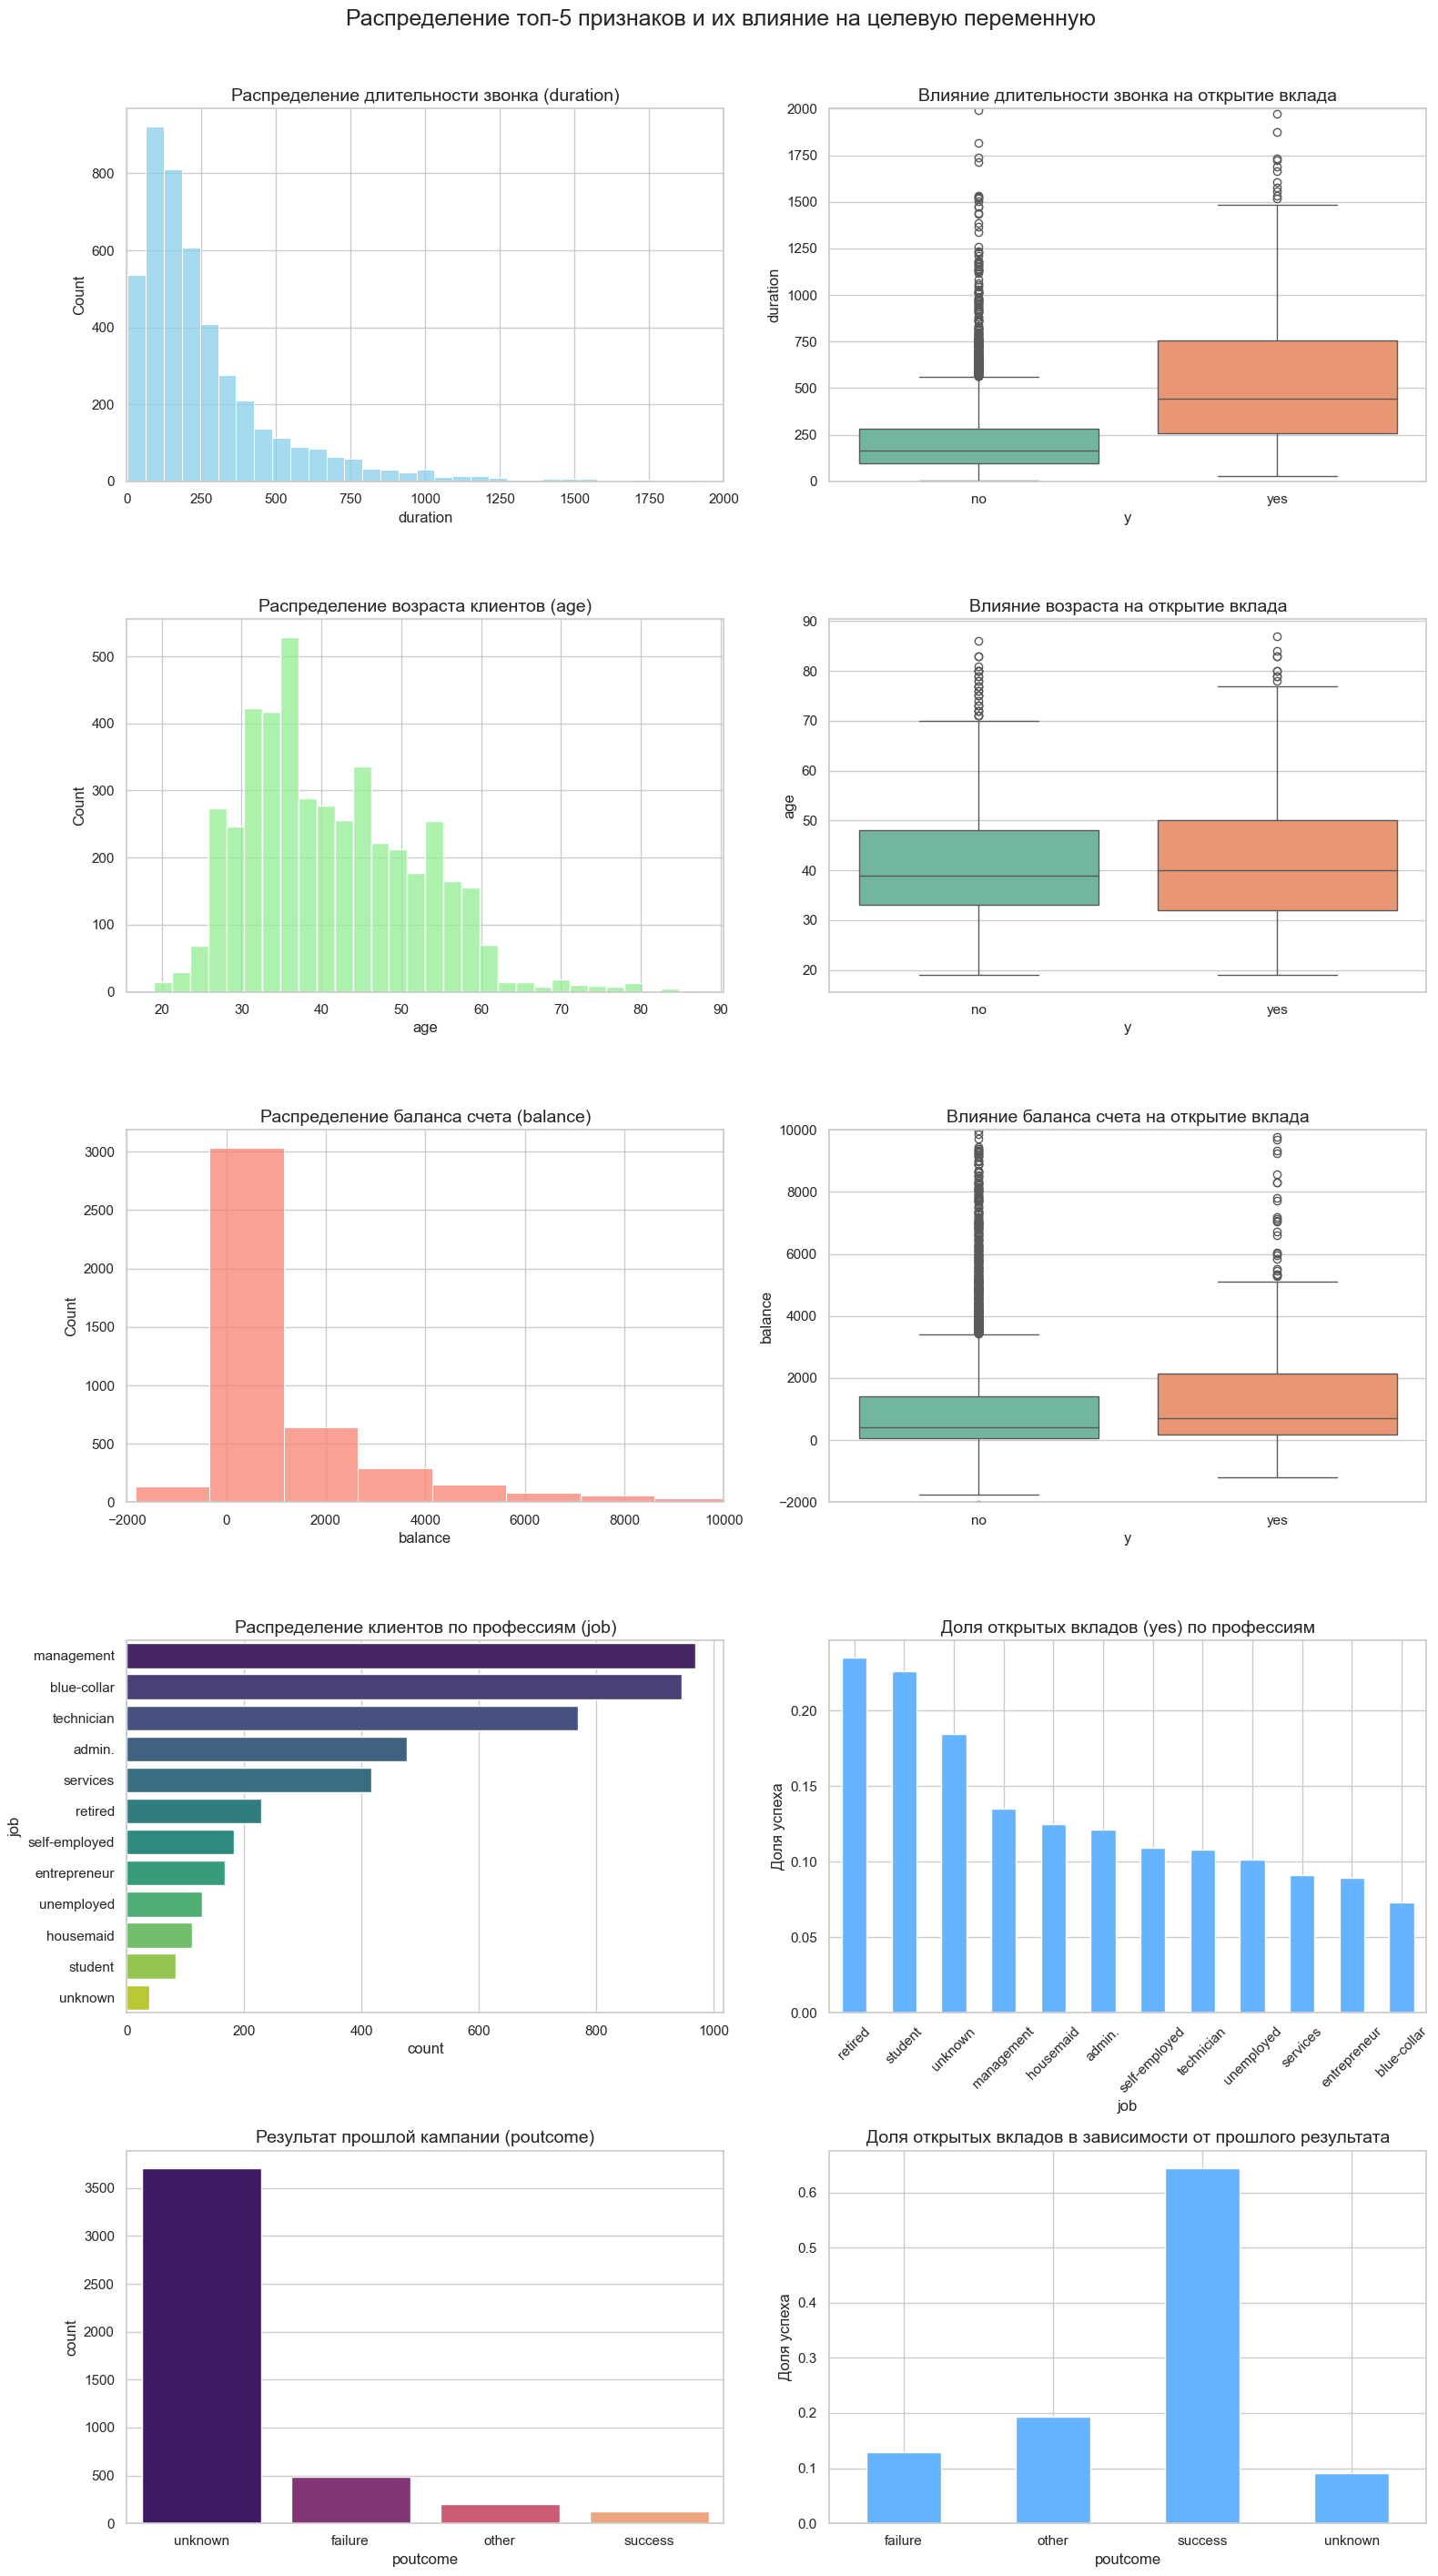

In [11]:
fig, axes = plt.subplots(5, 2, figsize=(16, 28))
fig.suptitle('Распределение топ-5 признаков и их влияние на целевую переменную', fontsize=18, y=1.01)

# --- 1. Признак DURATION ---
sns.histplot(data=df, x='duration', bins=50, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Распределение длительности звонка (duration)', fontsize=14)
axes[0, 0].set_xlim(0, 2000) # Ограничиваем экстремальные выбросы для наглядности

sns.boxplot(data=df, x='y', y='duration', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Влияние длительности звонка на открытие вклада', fontsize=14)
axes[0, 1].set_ylim(0, 2000)

# --- 2. Признак AGE ---
sns.histplot(data=df, x='age', bins=30, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Распределение возраста клиентов (age)', fontsize=14)

sns.boxplot(data=df, x='y', y='age', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Влияние возраста на открытие вклада', fontsize=14)

# --- 3. Признак BALANCE ---
sns.histplot(data=df, x='balance', bins=50, ax=axes[2, 0], color='salmon')
axes[2, 0].set_title('Распределение баланса счета (balance)', fontsize=14)
axes[2, 0].set_xlim(-2000, 10000) 

sns.boxplot(data=df, x='y', y='balance', ax=axes[2, 1], palette='Set2')
axes[2, 1].set_title('Влияние баланса счета на открытие вклада', fontsize=14)
axes[2, 1].set_ylim(-2000, 10000)

# --- 4. Признак JOB ---
sns.countplot(data=df, y='job', ax=axes[3, 0], palette='viridis', order=df['job'].value_counts().index)
axes[3, 0].set_title('Распределение клиентов по профессиям (job)', fontsize=14)

# Считаем долю 'yes' для каждой профессии
job_pct = df.groupby('job')['y'].value_counts(normalize=True).unstack()
job_pct = job_pct.sort_values(by='yes', ascending=False)
job_pct['yes'].plot(kind='bar', ax=axes[3, 1], color='#66b3ff')
axes[3, 1].set_title('Доля открытых вкладов (yes) по профессиям', fontsize=14)
axes[3, 1].set_ylabel('Доля успеха')
axes[3, 1].tick_params(axis='x', rotation=45)

# --- 5. Признак POUTCOME ---
sns.countplot(data=df, x='poutcome', ax=axes[4, 0], palette='magma')
axes[4, 0].set_title('Результат прошлой кампании (poutcome)', fontsize=14)

# Считаем долю 'yes' для результатов прошлой кампании
poutcome_pct = df.groupby('poutcome')['y'].value_counts(normalize=True).unstack()
poutcome_pct['yes'].plot(kind='bar', ax=axes[4, 1], color='#66b3ff')
axes[4, 1].set_title('Доля открытых вкладов в зависимости от прошлого результата', fontsize=14)
axes[4, 1].set_ylabel('Доля успеха')
axes[4, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Выводы по разведочному анализу (EDA)

На основе визуального и статистического анализа можно сформулировать следующие выводы:

1. **Дисбаланс классов:** Целевая переменная сильно несбалансирована. 88.3% клиентов ответили отказом, и только 11.7% открыли вклад. Это стандартная картина для телемаркетинга, требующая использования устойчивых к дисбалансу метрик (ROC-AUC, F1).
2. **Длительность звонка (duration):** Наблюдается сильнейшая прямая зависимость. Медианное время разговора с согласившимися клиентами более чем в 2 раза превышает время разговора при отказе.
3. **Возраст и Баланс:** Основную массу клиентов составляют люди 30-50 лет с небольшим балансом. При этом графики показывают, что пожилые люди (выбросы на boxplot возраста) и люди с более высокими накоплениями (75-й процентиль баланса) демонстрируют бóльшую склонность к открытию вклада.
4. **Профессия (job):** Чаще всего банк звонит «синим воротничкам» и менеджерам. Однако анализ конверсии показывает, что максимальную долю успешных сделок приносят студенты и пенсионеры. Рабочие специальности отказываются чаще всего.
5. **Предыстория (poutcome):** Подавляющее большинство клиентов ранее не контактировали с банком (статус `unknown`). Однако, если предыдущая маркетинговая кампания завершилась для клиента успехом (`success`), вероятность того, что он согласится открыть новый вклад, превышает 60%. Это самый сильный бизнес-предиктор лояльности.